<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-3-Holonomic-Mechanics/Untitled145.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Finding Geodesics on a Cone**

**Using Soft Constraints**

A unit-mass particle is constrained to move along the right circular upper cone
with apex at the origin and opening angle $\pi/4$, defined by the holonomic
constraint
$$
f(x,y,z)=x^2+y^2-z^2=0.
$$
We are interested in computing particle trajectories on the time interval
$t\in[0,4]$ starting from the initial position
$$
(x_0,y_0,z_0)=(1,0,1),
$$
with three different initial velocities:
$$
v_{\mathrm{gen}}=(x_0,y_0,z_0)=(1,0,1), \quad
v_{\mathrm{circ}}=(-y_0,x_0,0)=(0,1,0), \quad
v_{\mathrm{slant}}=(1,2,1).
$$

The next code provides the geodesics in the direction of $v_{gen}$ which is a line.

Epoch 200: loss = 2.7476e+00
Epoch 400: loss = 8.2951e-01
Epoch 600: loss = 5.9223e-01
Epoch 800: loss = 5.5740e-01
Epoch 1000: loss = 5.3116e-01


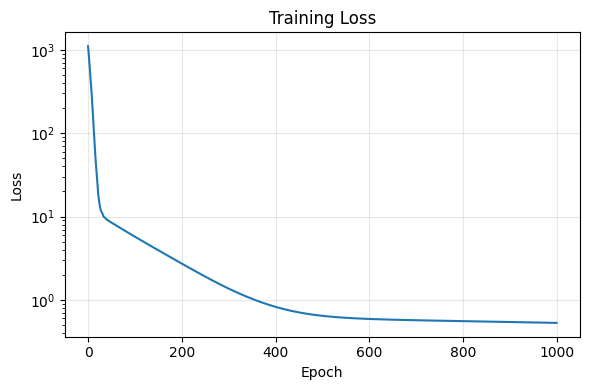

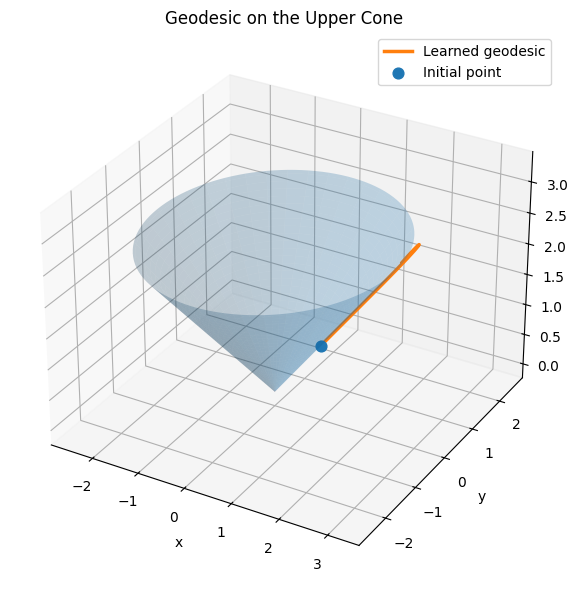

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ------------------------------------------------------------
# Problem setup: upper cone x^2 + y^2 - z^2 = 0, z >= 0
# ------------------------------------------------------------

# Initial position and velocity
q0_np = np.array([1.0, 0.0, 1.0], dtype=np.float32)
v0_np = np.array([1.0, 0.0, 1.0], dtype=np.float32)  #along th egenerator line
#v0_np = np.array([0.0, 1.0, 0.0], dtype=np.float32)  #along a horizontal circle
#v0_np = np.array([1.0, 2.0, 1.0], dtype=np.float32)   #slant direction

q0 = tf.constant(q0_np.reshape(1, 3))
v0 = tf.constant(v0_np.reshape(1, 3))

T_final = 4.0
M = 500

t_colloc = np.linspace(0.0, T_final, M, dtype=np.float32).reshape(-1, 1)
t_colloc_tf = tf.constant(t_colloc)

# ------------------------------------------------------------
# Neural network for correction term
# q_theta(t) = q0 + t v0 + t^2 nn_theta(t)
# ------------------------------------------------------------

def build_net():
    return keras.Sequential([
        layers.Input(shape=(1,)),
        layers.Dense(64, activation="swish"),
        #layers.Dense(64, activation="swish"),
        layers.Dense(3)
    ])

nn = build_net()
optimizer = keras.optimizers.Adam(1e-3)

def q_theta(t):
    return q0 + t * v0 + (t**2) * nn(t)

# ------------------------------------------------------------
# Constraint and gradient
# ------------------------------------------------------------

def f_cone(q):
    return q[:, 0]**2 + q[:, 1]**2 - q[:, 2]**2

def grad_f_cone(q):
    return tf.stack([2*q[:, 0], 2*q[:, 1], -2*q[:, 2]], axis=1)

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

mu1, mu2, mu3 = 1.0, 1.0, 1.0
EPOCHS = 1000

loss_hist = []

dataset = tf.data.Dataset.from_tensor_slices(t_colloc_tf).batch(M)

for epoch in range(EPOCHS):
    for t_batch in dataset:
        with tf.GradientTape(persistent=True) as tape:
            tape.watch(t_batch)

            q = q_theta(t_batch)
            dq_dt = tf.squeeze(
                tape.batch_jacobian(q, t_batch), axis=-1
            )

            # Constraint loss
            loss_cone = tf.reduce_mean(f_cone(q)**2)

            # Tangency loss
            tang = tf.reduce_sum(grad_f_cone(q) * dq_dt, axis=1)
            loss_tan = tf.reduce_mean(tang**2)

            # Kinetic energy
            loss_kin = 0.5 * tf.reduce_mean(
                tf.reduce_sum(dq_dt**2, axis=1)
            )

            loss = mu1*loss_cone + mu2*loss_tan + mu3*loss_kin

        grads = tape.gradient(loss, nn.trainable_variables)
        optimizer.apply_gradients(zip(grads, nn.trainable_variables))
        del tape

    loss_hist.append(loss.numpy())
    if (epoch+1) % 200 == 0:
        print(f"Epoch {epoch+1}: loss = {loss_hist[-1]:.4e}")

# ------------------------------------------------------------
# Plot loss
# ------------------------------------------------------------

plt.figure(figsize=(6,4))
plt.plot(loss_hist)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot cone + learned geodesic
# ------------------------------------------------------------

# Learned trajectory
t_plot = np.linspace(0.0, T_final, 400, dtype=np.float32).reshape(-1, 1)
q_plot = q_theta(tf.constant(t_plot)).numpy()

# Cone surface
r = np.linspace(0.0, 2.5, 60)
theta = np.linspace(0.0, 2*np.pi, 120)
R, Theta = np.meshgrid(r, theta)
Xc = R * np.cos(Theta)
Yc = R * np.sin(Theta)
Zc = R  # upper cone: z = sqrt(x^2+y^2)

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection="3d")

# Cone
ax.plot_surface(Xc, Yc, Zc, alpha=0.25, linewidth=0)

# Geodesic
ax.plot(q_plot[:,0], q_plot[:,1], q_plot[:,2],
        linewidth=2.5, label="Learned geodesic")

# Initial point
ax.scatter(*q0_np, s=60, label="Initial point")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Geodesic on the Upper Cone")
ax.legend()

plt.tight_layout()
plt.show()


The next code provides the geodesics in the direction of $v_{circ}$ which is a piece of a spiral.
Although the initial velocity $v_{\mathrm{circ}}$ is tangent to the horizontal
circle $z=z_0$, such circles are not geodesics on the cone. Geodesics on a cone
correspond to straight lines in its planar development and, except for the
generators, appear as spiral curves when embedded in $\mathbb{R}^3$.


Epoch 200: loss = 1.5633e+00
Epoch 400: loss = 4.4800e-01
Epoch 600: loss = 3.1737e-01
Epoch 800: loss = 2.7875e-01
Epoch 1000: loss = 2.5070e-01


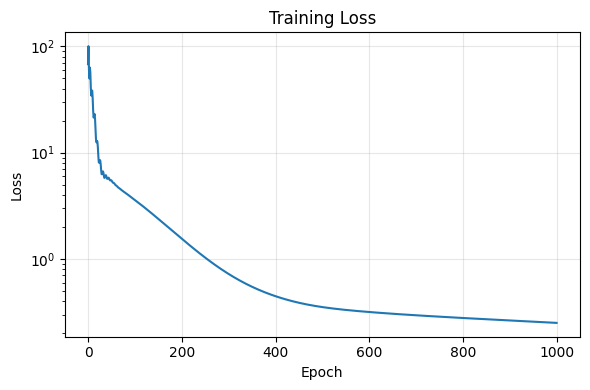

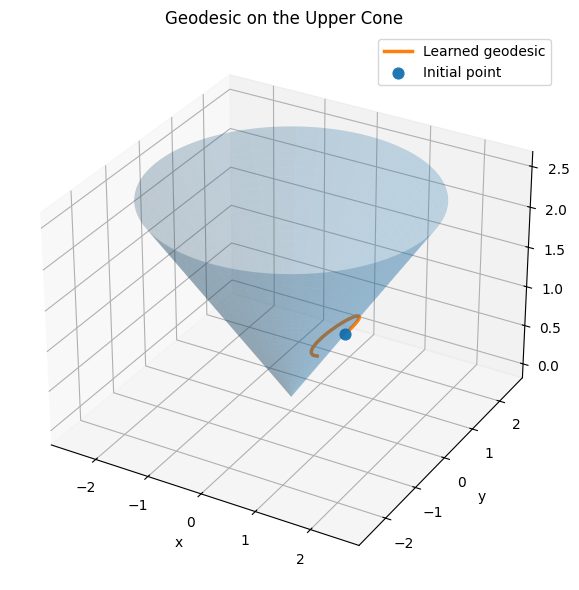

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ------------------------------------------------------------
# Problem setup: upper cone x^2 + y^2 - z^2 = 0, z >= 0
# ------------------------------------------------------------

# Initial position and velocity
q0_np = np.array([1.0, 0.0, 1.0], dtype=np.float32)
#v0_np = np.array([1.0, 0.0, 1.0], dtype=np.float32)  #along th egenerator line
v0_np = np.array([0.0, 1.0, 0.0], dtype=np.float32)  #along a horizontal circle
#v0_np = np.array([1.0, 2.0, 1.0], dtype=np.float32)   #slant direction

q0 = tf.constant(q0_np.reshape(1, 3))
v0 = tf.constant(v0_np.reshape(1, 3))

T_final = 4.0
M = 500

t_colloc = np.linspace(0.0, T_final, M, dtype=np.float32).reshape(-1, 1)
t_colloc_tf = tf.constant(t_colloc)

# ------------------------------------------------------------
# Neural network for correction term
# q_theta(t) = q0 + t v0 + t^2 nn_theta(t)
# ------------------------------------------------------------

def build_net():
    return keras.Sequential([
        layers.Input(shape=(1,)),
        layers.Dense(64, activation="swish"),
        #layers.Dense(64, activation="swish"),
        layers.Dense(3)
    ])

nn = build_net()
optimizer = keras.optimizers.Adam(1e-3)

def q_theta(t):
    return q0 + t * v0 + (t**2) * nn(t)

# ------------------------------------------------------------
# Constraint and gradient
# ------------------------------------------------------------

def f_cone(q):
    return q[:, 0]**2 + q[:, 1]**2 - q[:, 2]**2

def grad_f_cone(q):
    return tf.stack([2*q[:, 0], 2*q[:, 1], -2*q[:, 2]], axis=1)

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

mu1, mu2, mu3 = 1.0, 1.0, 1.0
EPOCHS = 1000

loss_hist = []

dataset = tf.data.Dataset.from_tensor_slices(t_colloc_tf).batch(M)

for epoch in range(EPOCHS):
    for t_batch in dataset:
        with tf.GradientTape(persistent=True) as tape:
            tape.watch(t_batch)

            q = q_theta(t_batch)
            dq_dt = tf.squeeze(
                tape.batch_jacobian(q, t_batch), axis=-1
            )

            # Constraint loss
            loss_cone = tf.reduce_mean(f_cone(q)**2)

            # Tangency loss
            tang = tf.reduce_sum(grad_f_cone(q) * dq_dt, axis=1)
            loss_tan = tf.reduce_mean(tang**2)

            # Kinetic energy
            loss_kin = 0.5 * tf.reduce_mean(
                tf.reduce_sum(dq_dt**2, axis=1)
            )

            loss = mu1*loss_cone + mu2*loss_tan + mu3*loss_kin

        grads = tape.gradient(loss, nn.trainable_variables)
        optimizer.apply_gradients(zip(grads, nn.trainable_variables))
        del tape

    loss_hist.append(loss.numpy())
    if (epoch+1) % 200 == 0:
        print(f"Epoch {epoch+1}: loss = {loss_hist[-1]:.4e}")

# ------------------------------------------------------------
# Plot loss
# ------------------------------------------------------------

plt.figure(figsize=(6,4))
plt.plot(loss_hist)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot cone + learned geodesic
# ------------------------------------------------------------

# Learned trajectory
t_plot = np.linspace(0.0, T_final, 400, dtype=np.float32).reshape(-1, 1)
q_plot = q_theta(tf.constant(t_plot)).numpy()

# Cone surface
r = np.linspace(0.0, 2.5, 60)
theta = np.linspace(0.0, 2*np.pi, 120)
R, Theta = np.meshgrid(r, theta)
Xc = R * np.cos(Theta)
Yc = R * np.sin(Theta)
Zc = R  # upper cone: z = sqrt(x^2+y^2)

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection="3d")

# Cone
ax.plot_surface(Xc, Yc, Zc, alpha=0.25, linewidth=0)

# Geodesic
ax.plot(q_plot[:,0], q_plot[:,1], q_plot[:,2],
        linewidth=2.5, label="Learned geodesic")

# Initial point
ax.scatter(*q0_np, s=60, label="Initial point")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Geodesic on the Upper Cone")
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
The next code provides the geodesics in the direction of $v_{slant}$ which is a spiral.

Epoch 200: loss = 1.7528e+01
Epoch 400: loss = 1.3906e+01
Epoch 600: loss = 1.0519e+01
Epoch 800: loss = 7.7154e+00
Epoch 1000: loss = 5.5755e+00
Epoch 1200: loss = 4.0800e+00
Epoch 1400: loss = 3.1261e+00
Epoch 1600: loss = 2.5201e+00
Epoch 1800: loss = 2.1061e+00
Epoch 2000: loss = 1.8143e+00


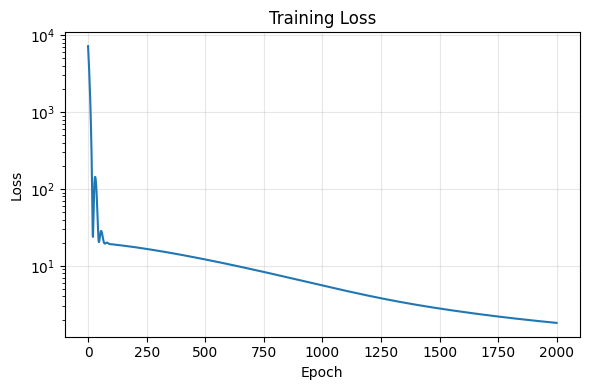

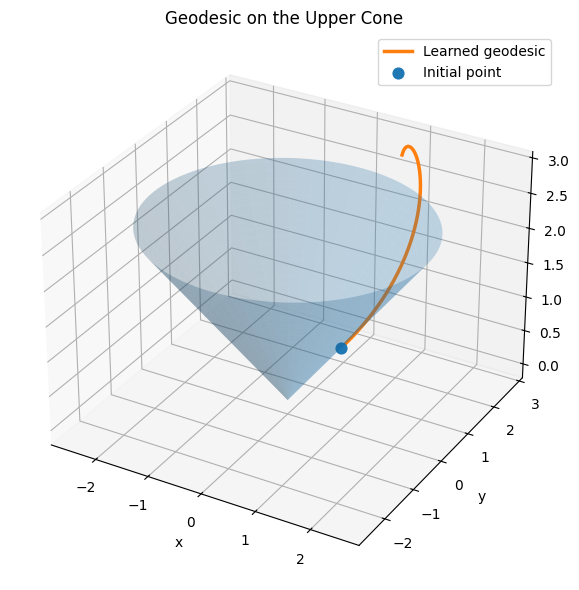

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ------------------------------------------------------------
# Problem setup: upper cone x^2 + y^2 - z^2 = 0, z >= 0
# ------------------------------------------------------------

# Initial position and velocity
q0_np = np.array([1.0, 0.0, 1.0], dtype=np.float32)
#v0_np = np.array([1.0, 0.0, 1.0], dtype=np.float32)  #along the generator line
#v0_np = np.array([0.0, 1.0, 0.0], dtype=np.float32)  #tangent to  a horizontal circle
v0_np = np.array([1.0, 2.0, 1.0], dtype=np.float32)   #slant direction

q0 = tf.constant(q0_np.reshape(1, 3))
v0 = tf.constant(v0_np.reshape(1, 3))

T_final = 3.0
M = 500

t_colloc = np.linspace(0.0, T_final, M, dtype=np.float32).reshape(-1, 1)
t_colloc_tf = tf.constant(t_colloc)

# ------------------------------------------------------------
# Neural network for correction term
# q_theta(t) = q0 + t v0 + t^2 nn_theta(t)
# ------------------------------------------------------------

def build_net():
    return keras.Sequential([
        layers.Input(shape=(1,)),
        layers.Dense(64, activation="swish"),
        #layers.Dense(64, activation="swish"),
        layers.Dense(3)
    ])

nn = build_net()
optimizer = keras.optimizers.Adam(1e-3)

def q_theta(t):
    return q0 + t * v0 + (t**2) * nn(t)

# ------------------------------------------------------------
# Constraint and gradient
# ------------------------------------------------------------

def f_cone(q):
    return q[:, 0]**2 + q[:, 1]**2 - q[:, 2]**2

def grad_f_cone(q):
    return tf.stack([2*q[:, 0], 2*q[:, 1], -2*q[:, 2]], axis=1)

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

mu1, mu2, mu3 = 1.0, 1.0, 1.0
EPOCHS = 2000

loss_hist = []

dataset = tf.data.Dataset.from_tensor_slices(t_colloc_tf).batch(M)

for epoch in range(EPOCHS):
    for t_batch in dataset:
        with tf.GradientTape(persistent=True) as tape:
            tape.watch(t_batch)

            q = q_theta(t_batch)
            dq_dt = tf.squeeze(
                tape.batch_jacobian(q, t_batch), axis=-1
            )

            # Constraint loss
            loss_cone = tf.reduce_mean(f_cone(q)**2)

            # Tangency loss
            tang = tf.reduce_sum(grad_f_cone(q) * dq_dt, axis=1)
            loss_tan = tf.reduce_mean(tang**2)

            # Kinetic energy
            loss_kin = 0.5 * tf.reduce_mean(
                tf.reduce_sum(dq_dt**2, axis=1)
            )

            loss = mu1*loss_cone + mu2*loss_tan + mu3*loss_kin

        grads = tape.gradient(loss, nn.trainable_variables)
        optimizer.apply_gradients(zip(grads, nn.trainable_variables))
        del tape

    loss_hist.append(loss.numpy())
    if (epoch+1) % 200 == 0:
        print(f"Epoch {epoch+1}: loss = {loss_hist[-1]:.4e}")

# ------------------------------------------------------------
# Plot loss
# ------------------------------------------------------------

plt.figure(figsize=(6,4))
plt.plot(loss_hist)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot cone + learned geodesic
# ------------------------------------------------------------

# Learned trajectory
t_plot = np.linspace(0.0, T_final, 400, dtype=np.float32).reshape(-1, 1)
q_plot = q_theta(tf.constant(t_plot)).numpy()

# Cone surface
r = np.linspace(0.0, 2.5, 60)
theta = np.linspace(0.0, 2*np.pi, 120)
R, Theta = np.meshgrid(r, theta)
Xc = R * np.cos(Theta)
Yc = R * np.sin(Theta)
Zc = R  # upper cone: z = sqrt(x^2+y^2)

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection="3d")

# Cone
ax.plot_surface(Xc, Yc, Zc, alpha=0.25, linewidth=0)

# Geodesic
ax.plot(q_plot[:,0], q_plot[:,1], q_plot[:,2],
        linewidth=2.5, label="Learned geodesic")

# Initial point
ax.scatter(*q0_np, s=60, label="Initial point")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Geodesic on the Upper Cone")
ax.legend()

plt.tight_layout()
plt.show()
